# CONSTELLATION: Spatial LR Analysis of Human Ovarian Cancer

This notebook demonstrates the CONSTELLATION pipeline on the **10x Xenium human ovarian cancer** dataset, with per-compartment analysis and multi-method benchmarking.

**Dataset**: 265K cells, 5,101 genes (Xenium Prime 5K), 17 cell types, 3 spatial compartments  
**Method**: CONSTELLATION uses a spatial-conditioned analytical test with kernel-weighted neighborhoods to detect ligand–receptor interactions enriched beyond expectation.

## Outline
1. Data loading & spatial overview
2. LR database & spatial graph
3. Run CONSTELLATION per compartment
4. Results overview & compartment comparison
5. Multi-method benchmarking (5 methods)
6. Biological validation: CXCL12–CXCR4 immune exclusion
7. Summary

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import constellation as cst
from scipy.sparse import issparse
from scipy.spatial import cKDTree
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print(f'CONSTELLATION version: {cst.__version__}')

CONSTELLATION version: 0.3.0


In [2]:
# Paths
DATA_PATH = 'data/xenium_oc_annotated.h5ad'
OUTPUT_PATH = 'results/constellation_celltype_results.csv'

# CONSTELLATION parameters
K = 10
TAU = 7.0              # µm (median NN1 ~ 6.8 µm)
MIN_EXPR_FRAC = 0.05
MIN_CELLS = 50
FDR_METHOD = 'fdr_bh'
FDR_THRESHOLD = 0.05

COMPARTMENTS = ['Tumor', 'Interface', 'Stroma']
CELL_TYPE_COL = 'cell_type'

In [3]:
# Load annotated data (produced by tutorial_annotate_oc.ipynb)
adata = sc.read_h5ad(DATA_PATH)
print(f'Total cells: {adata.n_obs:,}')
print(f'Total genes: {adata.n_vars:,}')

# Filter unassigned cells
adata = adata[adata.obs[CELL_TYPE_COL] != 'Unassigned'].copy()
print(f'Assigned cells: {adata.n_obs:,}')

# Reverse log1p — CONSTELLATION applies log1p internally,
# so input should be normalized counts (not log-transformed)
if issparse(adata.X):
    adata.X.data = np.expm1(adata.X.data)
else:
    adata.X = np.expm1(adata.X)
print('Reversed log1p (expm1) for CONSTELLATION input')

# Cell type distribution
ct_counts = adata.obs[CELL_TYPE_COL].value_counts()
print(f'\nCell types ({len(ct_counts)}):')
for ct, n in ct_counts.items():
    print(f'  {ct:<15s}: {n:>7,}')

Total cells: 265,387
Total genes: 5,101


Assigned cells: 214,426


Reversed log1p (expm1) for CONSTELLATION input

Cell types (17):
  Epithelial     :  92,280
  Tumor          :  48,653
  Fibroblast     :  28,271
  CAF            :   9,267
  Pericyte       :   7,075
  Monocyte       :   5,524
  SMC            :   5,436
  Macrophage     :   5,099
  Endothelial    :   5,000
  Myeloid        :   3,535
  T_cell         :   1,703
  T_CD8          :     802
  B_cell         :     787
  DC             :     651
  Plasma         :     182
  T_CD4          :     118
  Treg           :      43


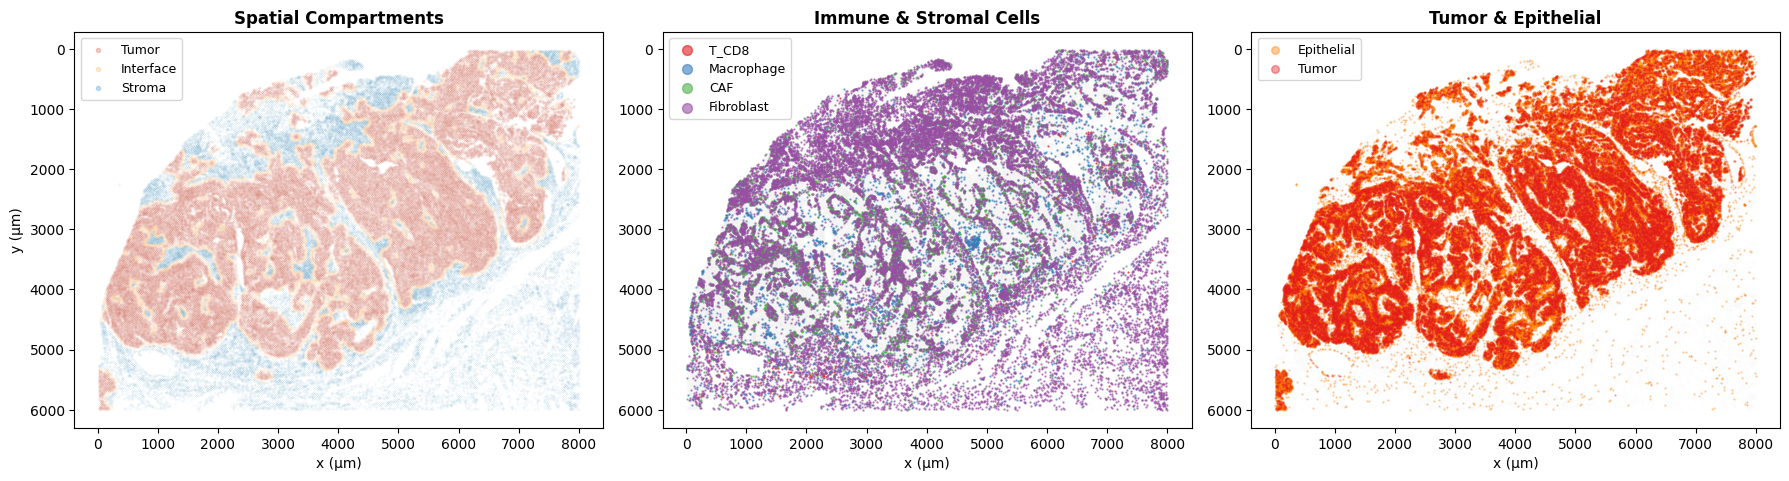

Cells per compartment:
  Tumor       : 149,042 (69.5%)
  Interface   :  24,324 (11.3%)
  Stroma      :  41,060 (19.1%)


In [4]:
# Spatial overview by compartment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = adata.obs['x_centroid'].values
y = adata.obs['y_centroid'].values
comp = adata.obs['compartment'].values
ct = adata.obs[CELL_TYPE_COL].values

# Panel 1: Compartments
ax = axes[0]
comp_colors = {'Tumor': '#d6604d', 'Interface': '#fdb863', 'Stroma': '#4393c3'}
for c, color in comp_colors.items():
    mask = comp == c
    ax.scatter(x[mask], y[mask], s=0.01, alpha=0.3, c=color, rasterized=True, label=c)
ax.set_title('Spatial Compartments', fontweight='bold')
ax.set_aspect('equal')
ax.invert_yaxis()
ax.legend(markerscale=30, fontsize=9)
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')

# Panel 2: Key immune cells
ax = axes[1]
ax.scatter(x, y, s=0.01, alpha=0.05, c='#dddddd', rasterized=True)
immune_colors = {'T_CD8': '#e41a1c', 'Macrophage': '#377eb8', 'CAF': '#4daf4a', 'Fibroblast': '#984ea3'}
for ctype, color in immune_colors.items():
    mask = ct == ctype
    ax.scatter(x[mask], y[mask], s=0.5, alpha=0.6, c=color, rasterized=True, label=ctype)
ax.set_title('Immune & Stromal Cells', fontweight='bold')
ax.set_aspect('equal')
ax.invert_yaxis()
ax.legend(markerscale=10, fontsize=9)
ax.set_xlabel('x (µm)')

# Panel 3: Tumor cells
ax = axes[2]
ax.scatter(x, y, s=0.01, alpha=0.05, c='#dddddd', rasterized=True)
tumor_mask = ct == 'Tumor'
epi_mask = ct == 'Epithelial'
ax.scatter(x[epi_mask], y[epi_mask], s=0.3, alpha=0.4, c='#ff7f00', rasterized=True, label='Epithelial')
ax.scatter(x[tumor_mask], y[tumor_mask], s=0.3, alpha=0.4, c='#e41a1c', rasterized=True, label='Tumor')
ax.set_title('Tumor & Epithelial', fontweight='bold')
ax.set_aspect('equal')
ax.invert_yaxis()
ax.legend(markerscale=10, fontsize=9)
ax.set_xlabel('x (µm)')

plt.tight_layout()
plt.show()

# Compartment summary
print('Cells per compartment:')
for c in COMPARTMENTS:
    n = (comp == c).sum()
    print(f'  {c:<12}: {n:>7,} ({n/len(comp)*100:.1f}%)')

---
## 2. LR Database & Spatial Graph

In [5]:
# Load consensus LR database (LIANA)
lr_df, lr_pairs = cst.load_lr_resource('consensus', adata=adata)
print(f'Testable LR pairs: {len(lr_pairs):,}')

# Check key immune exclusion pairs
KEY_PAIRS = [
    ('CXCL12', 'CXCR4', 'Immune exclusion (T cell trapping)'),
    ('CSF1', 'CSF1R', 'Macrophage recruitment'),
    ('CD274', 'PDCD1', 'PD-L1/PD-1 checkpoint'),
    ('CD47', 'SIRPA', 'Anti-phagocytic signal'),
    ('TGFB1', 'TGFBR1', 'Immunosuppression'),
]

print('\nKey literature pairs:')
for lig, rec, desc in KEY_PAIRS:
    found = (lig, rec) in lr_pairs
    in_panel = lig in adata.var_names and rec in adata.var_names
    if found:
        print(f'  {lig}-{rec}: in database & panel ({desc})')
    elif in_panel:
        print(f'  {lig}-{rec}: genes in panel but NOT in LR database')
    else:
        missing = [g for g in [lig, rec] if g not in adata.var_names]
        print(f'  {lig}-{rec}: {" ".join(missing)} NOT in panel ({desc})')

Resource: consensus (4624 pairs total)
Filtered to genes in adata: 1382 testable pairs
Testable LR pairs: 1,382

Key literature pairs:
  CXCL12-CXCR4: in database & panel (Immune exclusion (T cell trapping))
  CSF1-CSF1R: genes in panel but NOT in LR database
  CD274-PDCD1: in database & panel (PD-L1/PD-1 checkpoint)
  CD47-SIRPA: in database & panel (Anti-phagocytic signal)
  TGFB1-TGFBR1: genes in panel but NOT in LR database


---
## 3. Run CONSTELLATION Per Compartment

CONSTELLATION tests each (cell-type pair, LR pair) combination using an **analytical permutation test**:

1. **Test statistic** $T = \mathbf{L}^\top \mathbf{w}$: for each sender cell, its ligand expression $L_i$ is weighted by the kernel-weighted receptor signal $w_i = \sum_j K(d_{ij}) R_j$ from receiver neighbors.
2. **Null distribution**: Under random permutation of cell labels, the exact moments $E[T]$ and $\text{Var}[T]$ are computed analytically.
3. **z-score**: $(T_{\text{obs}} - E[T]) / \sqrt{\text{Var}[T]}$, with p-value from normal approximation.
4. **FDR correction**: Benjamini-Hochberg per compartment.

The analysis is run independently on each compartment (Tumor, Interface, Stroma) with a compartment-specific spatial graph.

In [6]:
import os

if os.path.exists(OUTPUT_PATH):
    print(f'Pre-computed results found: {OUTPUT_PATH}')
    print('Skipping CONSTELLATION run (delete file to recompute)')
    combined = pd.read_csv(OUTPUT_PATH)
    combined['significant'] = (combined['p_adj'] < 0.05) & (combined['z_score'] > 0)
    print(f'Loaded: {len(combined):,} tests, {combined["significant"].sum():,} significant')
else:
    all_results = []

    for comp_name in COMPARTMENTS:
        print(f'\n{"=" * 60}')
        print(f'COMPARTMENT: {comp_name}')
        print(f'{"=" * 60}')
        
        # Subset to compartment
        comp_mask = adata.obs['compartment'] == comp_name
        adata_sub = adata[comp_mask].copy()
        print(f'Cells: {adata_sub.n_obs:,}')
        
        # Cell types with enough cells
        ct_counts = adata_sub.obs[CELL_TYPE_COL].value_counts()
        testable = ct_counts[ct_counts >= MIN_CELLS]
        print(f'Cell types >= {MIN_CELLS}: {len(testable)}')
        for ct_name, n in testable.items():
            print(f'  {ct_name}: {n:,}')
        
        # Build spatial graph on compartment subset
        print(f'\nBuilding spatial graph (k={K})...')
        indices, distances = cst.build_spatial_graph(adata_sub, k=K)
        median_nn1 = np.median(distances[:, 0])
        print(f'Median NN1: {median_nn1:.2f} µm')
        
        # Run CONSTELLATION
        print(f'\nRunning CONSTELLATION (tau={TAU})...')
        t0 = time.time()
        results = cst.run_celltype_analysis(
            adata=adata_sub,
            cell_type_col=CELL_TYPE_COL,
            lr_pairs=lr_pairs,
            indices=indices,
            distances=distances,
            tau=TAU,
            min_expr_frac=MIN_EXPR_FRAC,
            min_cells=MIN_CELLS,
            fdr_method=FDR_METHOD,
            fdr_threshold=FDR_THRESHOLD,
            verbose=True,
        )
        elapsed = time.time() - t0
        
        results['compartment'] = comp_name
        results['significant'] = (results['p_adj'] < FDR_THRESHOLD) & (results['z_score'] > 0)
        n_sig = results['significant'].sum()
        
        print(f'Done in {elapsed:.1f}s')
        print(f'Tests: {len(results):,}, Significant: {n_sig:,} ({n_sig/len(results)*100:.1f}%)')
        
        all_results.append(results)

    # Combine
    combined = pd.concat(all_results, ignore_index=True)
    combined.to_csv(OUTPUT_PATH, index=False)
    print(f'\nSaved: {OUTPUT_PATH}')
    print(f'Total: {len(combined):,} tests, {combined["significant"].sum():,} significant')

Pre-computed results found: results/constellation_celltype_results.csv
Skipping CONSTELLATION run (delete file to recompute)
Loaded: 50,421 tests, 2,786 significant


---
## 4. Results Overview

In [7]:
# Load pre-computed results (skip this cell if running from scratch above)
combined = pd.read_csv(OUTPUT_PATH)
combined['significant'] = (combined['p_adj'] < 0.05) & (combined['z_score'] > 0)

sig = combined[combined['significant']]
print(f'Total tests: {len(combined):,}')
print(f'Significant: {len(sig):,} ({len(sig)/len(combined)*100:.1f}%)')

print(f'\nPer compartment:')
for c in COMPARTMENTS:
    sub = combined[combined['compartment'] == c]
    n_sig = sub['significant'].sum()
    print(f'  {c:<12}: {n_sig:,} / {len(sub):,} ({n_sig/len(sub)*100:.1f}%)')

Total tests: 50,421
Significant: 2,786 (5.5%)

Per compartment:
  Tumor       : 1,061 / 18,466 (5.7%)
  Interface   : 692 / 17,032 (4.1%)
  Stroma      : 1,033 / 14,923 (6.9%)


In [8]:
# Top 20 significant interactions by z-score
top = sig.nlargest(20, 'z_score')

print(f'{"Ligand":<10} {"Receptor":<10} {"Sender":<15} {"Receiver":<15} {"Comp":<10} {"z":>7} {"p_adj":>10} {"FE":>6}')
print('-' * 85)
for _, r in top.iterrows():
    print(f'{r["ligand"]:<10} {r["receptor"]:<10} '
          f'{r["sender"]:<15} {r["receiver"]:<15} '
          f'{r["compartment"]:<10} '
          f'{r["z_score"]:>7.2f} {r["p_adj"]:>10.2e} {r["fold_enrichment"]:>6.2f}')

Ligand     Receptor   Sender          Receiver        Comp             z      p_adj     FE
-------------------------------------------------------------------------------------
VEGFA      EGFR       Epithelial      Epithelial      Tumor        39.76   0.00e+00   1.50
CCN1       ITGB5      Epithelial      Fibroblast      Tumor        32.16   0.00e+00   2.27
CTHRC1     ROR2       Epithelial      CAF             Tumor        30.26   0.00e+00   5.89
CCN1       ITGB5      Epithelial      CAF             Tumor        28.33   0.00e+00   2.44
COL4A2     ITGB5      Epithelial      CAF             Tumor        26.89   0.00e+00   2.99
DCN        EGFR       Epithelial      CAF             Tumor        25.33   0.00e+00   5.68
CTHRC1     ROR2       Epithelial      Fibroblast      Tumor        24.92   0.00e+00   4.59
COL4A1     CD93       Epithelial      Endothelial     Tumor        24.39   0.00e+00   5.54
COL4A1     CD93       Fibroblast      Endothelial     Stroma       23.51   0.00e+00   2.93
POST

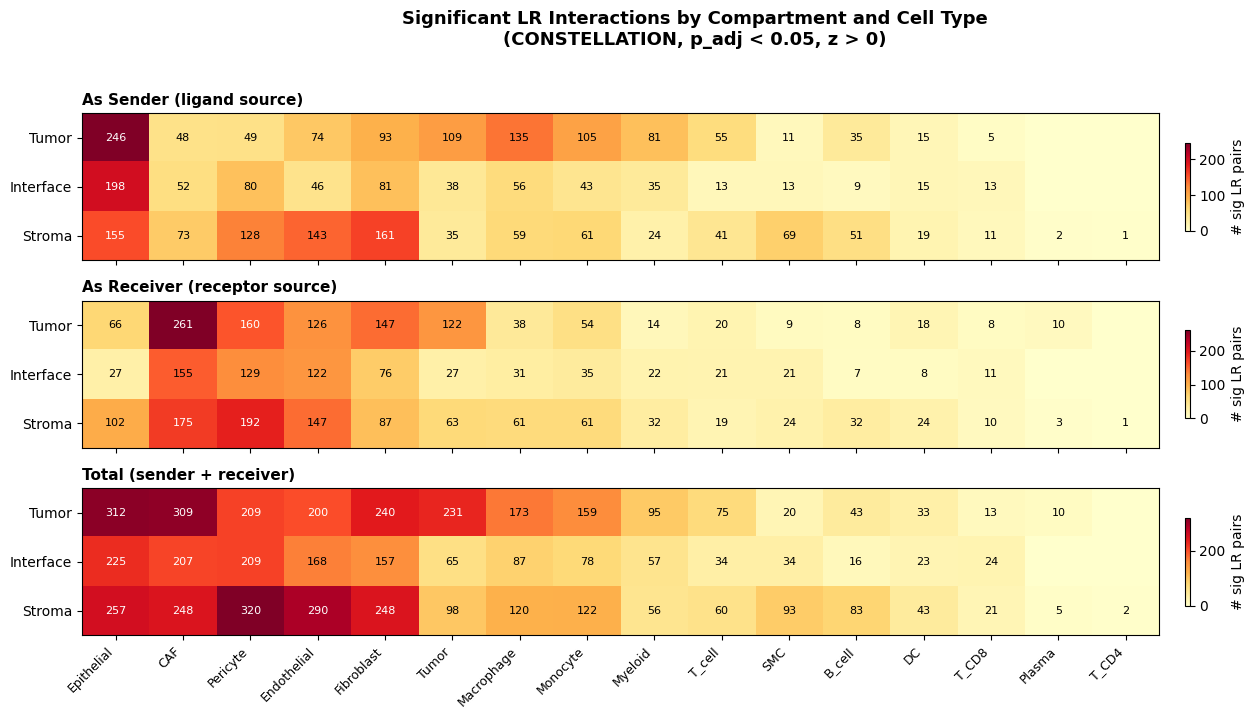

In [9]:
# Heatmap: significant LR pairs per cell type per compartment
sender_counts = sig.groupby(['compartment', 'sender']).size().unstack(fill_value=0)
receiver_counts = sig.groupby(['compartment', 'receiver']).size().unstack(fill_value=0)

all_types = sorted(
    set(sender_counts.columns) | set(receiver_counts.columns),
    key=lambda ct: (sender_counts[ct].sum() if ct in sender_counts.columns else 0) +
                   (receiver_counts[ct].sum() if ct in receiver_counts.columns else 0),
    reverse=True,
)

send_mat = pd.DataFrame(0, index=COMPARTMENTS, columns=all_types)
recv_mat = pd.DataFrame(0, index=COMPARTMENTS, columns=all_types)
for c in COMPARTMENTS:
    if c in sender_counts.index:
        for ct_name in all_types:
            if ct_name in sender_counts.columns:
                send_mat.loc[c, ct_name] = sender_counts.loc[c, ct_name]
    if c in receiver_counts.index:
        for ct_name in all_types:
            if ct_name in receiver_counts.columns:
                recv_mat.loc[c, ct_name] = receiver_counts.loc[c, ct_name]

total_mat = send_mat + recv_mat

fig, axes = plt.subplots(3, 1, figsize=(14, 7), gridspec_kw={'height_ratios': [1, 1, 1]})
cmap = 'YlOrRd'

for ax, mat, title in [
    (axes[0], send_mat, 'As Sender (ligand source)'),
    (axes[1], recv_mat, 'As Receiver (receptor source)'),
    (axes[2], total_mat, 'Total (sender + receiver)'),
]:
    vm = mat.values.max()
    im = ax.imshow(mat.values.astype(float), cmap=cmap, aspect='auto', vmin=0, vmax=vm)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = int(mat.iloc[i, j])
            if val > 0:
                color = 'white' if val > vm * 0.6 else 'black'
                ax.text(j, i, str(val), ha='center', va='center', fontsize=8, color=color)
    ax.set_yticks(range(len(COMPARTMENTS)))
    ax.set_yticklabels(COMPARTMENTS, fontsize=10)
    ax.set_xticks(range(len(all_types)))
    if ax == axes[2]:
        ax.set_xticklabels(all_types, rotation=45, ha='right', fontsize=9)
    else:
        ax.set_xticklabels([])
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02, label='# sig LR pairs')

fig.suptitle('Significant LR Interactions by Compartment and Cell Type\n(CONSTELLATION, p_adj < 0.05, z > 0)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Top sender-receiver pairs
pair_summary = sig.groupby(['sender', 'receiver', 'compartment']).agg(
    n_sig=('ligand', 'count'),
    mean_z=('z_score', 'mean'),
    mean_fe=('fold_enrichment', 'mean'),
).reset_index().sort_values('n_sig', ascending=False)

print(f'Cell-type pairs with significant interactions: {len(pair_summary)}')
print(f'\n{"Sender":<15} {"Receiver":<15} {"Comp":<10} {"# sig":>6} {"mean z":>8} {"mean FE":>8}')
print('-' * 65)
for _, r in pair_summary.head(20).iterrows():
    print(f'{r["sender"]:<15} {r["receiver"]:<15} {r["compartment"]:<10} '
          f'{r["n_sig"]:>6} {r["mean_z"]:>8.2f} {r["mean_fe"]:>8.2f}')

Cell-type pairs with significant interactions: 411

Sender          Receiver        Comp        # sig   mean z  mean FE
-----------------------------------------------------------------
Epithelial      Tumor           Tumor          48     6.11     1.09
Epithelial      CAF             Tumor          45     9.94     2.05
Epithelial      CAF             Interface      43     7.77     2.19
Epithelial      Pericyte        Interface      40     5.52     2.39
Macrophage      CAF             Tumor          40     4.91     2.32
Endothelial     Pericyte        Stroma         38     5.23     1.85
Pericyte        Pericyte        Stroma         34     6.12     1.84
Myeloid         CAF             Tumor          33     4.42     2.54
Epithelial      Pericyte        Tumor          31     8.76     2.45
Endothelial     Endothelial     Stroma         31     4.82     1.64
Monocyte        CAF             Tumor          30     5.01     2.17
Tumor           Tumor           Tumor          29     6.19     1.1

---
## 5. Multi-Method Benchmarking

We compare CONSTELLATION against four alternative methods, all run on the same dataset per compartment:

| Method | Type | Null Model |
|:--|:--|:--|
| **CONSTELLATION** | Spatial, analytical | Kernel-weighted binomial |
| **CellPhoneDB+Spatial** | Non-spatial + post-hoc filter | Permutation (100) + spatial enrichment > 1.0 |
| **CellChat-Spatial** | Non-spatial + distance weighting | Permutation (100), law of mass action |
| **Colocalization** | Spatial, permutation | Permute R-expression labels (100) |
| **Coexpression** | Non-spatial, analytical | Binomial enrichment vs background |

In [11]:
# Load all benchmark results
const = combined.copy()
cpdb = pd.read_csv('results/benchmark_cellphonedb_oc.csv')
cc = pd.read_csv('results/benchmark_cellchat_spatial_oc.csv')
coloc = pd.read_csv('results/benchmark_coloc_oc.csv')
coexpr = pd.read_csv('results/benchmark_coexpression_oc.csv')

METHODS = {
    'CONSTELLATION': const,
    'CellPhoneDB+Spatial': cpdb,
    'CellChat-Spatial': cc,
    'Colocalization': coloc,
    'Coexpression': coexpr,
}

print(f'{"Method":<25} {"Total":>10} {"Significant":>12} {"Rate":>8}')
print('-' * 58)
for name, df in METHODS.items():
    n_sig = df['significant'].sum()
    print(f'{name:<25} {len(df):>10,} {n_sig:>12,} {n_sig/len(df)*100:>7.1f}%')

Method                         Total  Significant     Rate
----------------------------------------------------------
CONSTELLATION                 50,421        2,786     5.5%
CellPhoneDB+Spatial          100,961       25,535    25.3%
CellChat-Spatial             100,961          247     0.2%
Colocalization               422,190       40,799     9.7%
Coexpression                 422,190       25,880     6.1%


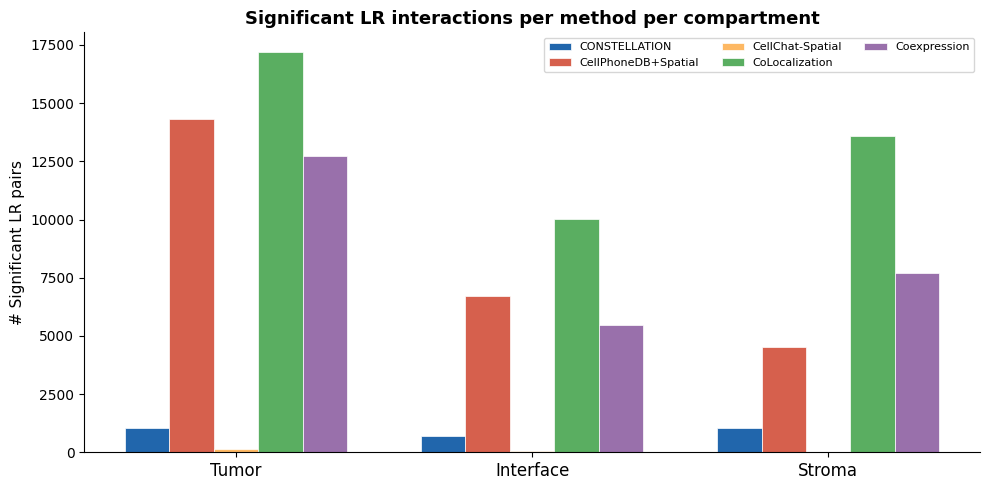


                               Tumor   Interface      Stroma
------------------------------------------------------------
CONSTELLATION                  1,061         692       1,033
CellPhoneDB+Spatial           14,318       6,715       4,502
CellChat-Spatial                 147          76          24
Colocalization                17,183      10,037      13,579
Coexpression                  12,714       5,449       7,717


In [12]:
# Significant interactions per method per compartment
METHOD_NAMES = list(METHODS.keys())
METHOD_COLORS = ['#2166ac', '#d6604d', '#fdb863', '#5aae61', '#9970ab']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(COMPARTMENTS))
width = 0.15

for i, (name, df) in enumerate(METHODS.items()):
    vals = []
    for c in COMPARTMENTS:
        sub = df[df['compartment'] == c]
        vals.append(sub['significant'].sum())
    ax.bar(x + (i - 2) * width, vals, width, label=name,
           color=METHOD_COLORS[i], edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(COMPARTMENTS, fontsize=12)
ax.set_ylabel('# Significant LR pairs', fontsize=11)
ax.set_title('Significant LR interactions per method per compartment',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Per-compartment table
print(f'\n{"":<25}', '  '.join(f'{c:>10}' for c in COMPARTMENTS))
print('-' * 60)
for name, df in METHODS.items():
    vals = [df[(df['compartment'] == c) & df['significant']].shape[0] for c in COMPARTMENTS]
    print(f'{name:<25}', '  '.join(f'{v:>10,}' for v in vals))

In [13]:
# Pairwise Jaccard similarity between methods
def get_sig_set(df):
    s = df[df['significant']]
    return set(zip(s['ligand'], s['receptor'], s['sender'], s['receiver'], s['compartment']))

sig_sets = {name: get_sig_set(df) for name, df in METHODS.items()}

print('Pairwise Jaccard similarity:')
print(f'{"":<18}', '  '.join(f'{n[:6]:>8}' for n in METHOD_NAMES))
for n1 in METHOD_NAMES:
    row = []
    for n2 in METHOD_NAMES:
        s1, s2 = sig_sets[n1], sig_sets[n2]
        union = len(s1 | s2)
        jaccard = len(s1 & s2) / union if union > 0 else 0
        row.append(f'{jaccard:>8.3f}')
    print(f'{n1[:17]:<18}', '  '.join(row))

Pairwise Jaccard similarity:
                     CONSTE    CellPh    CellCh    CoLoca    Coexpr
CONSTELLATION         1.000     0.041     0.007     0.041     0.028
CellPhoneDB+Spati     0.041     1.000     0.007     0.160     0.174
CellChat-Spatial      0.007     0.007     1.000     0.004     0.005
Colocalization        0.041     0.160     0.004     1.000     0.220
Coexpression          0.028     0.174     0.005     0.220     1.000


---
## 6. Biological Validation: CXCL12–CXCR4 Immune Exclusion

High-grade serous ovarian cancer (HGSOC) exhibits an **immune-excluded phenotype**: CD8+ T cells are trapped in the stroma by fibroblast-derived CXCL12 (SDF-1), which binds CXCR4 on T cells.

This is a textbook mechanism — CXCR4 inhibitors (AMD3100/plerixafor) are in clinical trials to overcome immune exclusion.

**Key question**: which method correctly identifies Fibroblast as the specific CXCL12 source for T_CD8 trapping, vs calling all cell types significant?

In [14]:
# CXCL12-CXCR4 → T_CD8: which senders are significant per method?
print('CXCL12-CXCR4 → T_CD8 specificity across methods:')
print('=' * 70)

for c in COMPARTMENTS:
    print(f'\n--- {c} ---')
    print(f'{"Method":<25} {"Sig senders":>12} {"Total":>8}  Significant senders')
    print('-' * 70)
    
    for name, df in METHODS.items():
        sub = df[(df['compartment'] == c) &
                 (df['ligand'] == 'CXCL12') & (df['receptor'] == 'CXCR4') &
                 (df['receiver'] == 'T_CD8')]
        sig_sub = sub[sub['significant']]
        senders = ', '.join(sorted(sig_sub['sender'].unique())) if len(sig_sub) > 0 else '(none)'
        print(f'{name:<25} {len(sig_sub):>12} / {len(sub):>5}  {senders}')

CXCL12-CXCR4 → T_CD8 specificity across methods:

--- Tumor ---
Method                     Sig senders    Total  Significant senders
----------------------------------------------------------------------
CONSTELLATION                        1 /     2  Fibroblast
CellPhoneDB+Spatial                 11 /    14  B_cell, CAF, Endothelial, Fibroblast, Macrophage, Monocyte, Myeloid, Pericyte, Plasma, T_CD8, T_cell
CellChat-Spatial                     0 /    14  (none)


Colocalization                       7 /    15  CAF, Endothelial, Epithelial, Fibroblast, Pericyte, Plasma, Tumor


Coexpression                         9 /    15  CAF, Endothelial, Fibroblast, Macrophage, Monocyte, Myeloid, Pericyte, Plasma, T_cell

--- Interface ---
Method                     Sig senders    Total  Significant senders
----------------------------------------------------------------------
CONSTELLATION                        0 /     6  (none)
CellPhoneDB+Spatial                 10 /    15  CAF, DC, Endothelial, Fibroblast, Macrophage, Monocyte, Myeloid, Plasma, T_CD8, T_cell
CellChat-Spatial                     0 /    15  (none)


Colocalization                       8 /    14  CAF, DC, Epithelial, Fibroblast, Macrophage, Monocyte, Myeloid, T_cell


Coexpression                         3 /    14  CAF, Fibroblast, Pericyte

--- Stroma ---
Method                     Sig senders    Total  Significant senders
----------------------------------------------------------------------
CONSTELLATION                        2 /    11  Epithelial, Fibroblast
CellPhoneDB+Spatial                 10 /    15  B_cell, CAF, DC, Macrophage, Monocyte, Myeloid, Plasma, T_CD4, T_CD8, T_cell
CellChat-Spatial                     0 /    15  (none)


Colocalization                      15 /    16  B_cell, CAF, DC, Endothelial, Epithelial, Fibroblast, Macrophage, Monocyte, Myeloid, Pericyte, SMC, T_CD4, T_CD8, T_cell, Tumor


Coexpression                         3 /    16  CAF, Fibroblast, Pericyte


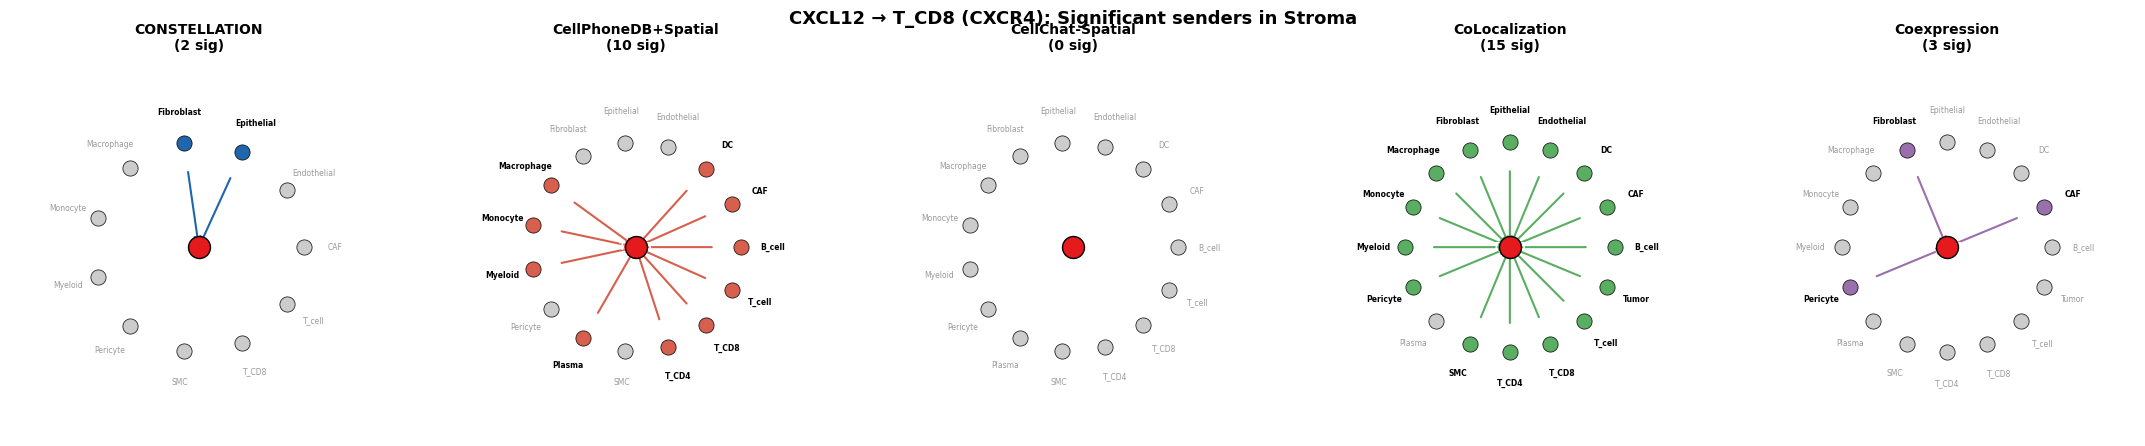


Interpretation:
  CONSTELLATION identifies the biologically specific CXCL12 sources (Fibroblast)
  CellPhoneDB+Spatial and Colocalization call most/all senders significant
  CellChat-Spatial is overly conservative (0 significant)


In [15]:
# Network plot: CXCL12 → T_CD8 per method (Stroma compartment)
COMP_SHOW = 'Stroma'

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for ax, (name, df), color in zip(axes, METHODS.items(), METHOD_COLORS):
    sub = df[(df['compartment'] == COMP_SHOW) &
             (df['ligand'] == 'CXCL12') & (df['receptor'] == 'CXCR4') &
             (df['receiver'] == 'T_CD8')]
    sig_sub = sub[sub['significant']]
    all_senders = sorted(sub['sender'].unique())
    sig_senders = set(sig_sub['sender'])
    
    # Place T_CD8 in center
    n = len(all_senders)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    radius = 1.0
    
    # Draw sender nodes in a circle
    for i, sender in enumerate(all_senders):
        sx, sy = radius * np.cos(angles[i]), radius * np.sin(angles[i])
        is_sig = sender in sig_senders
        node_color = color if is_sig else '#cccccc'
        ax.scatter(sx, sy, s=120, c=node_color, zorder=3, edgecolors='black', linewidth=0.5)
        ax.text(sx * 1.3, sy * 1.3, sender, fontsize=5.5, ha='center', va='center',
                fontweight='bold' if is_sig else 'normal',
                color='black' if is_sig else '#999999')
        if is_sig:
            ax.annotate('', xy=(0, 0), xytext=(sx * 0.75, sy * 0.75),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    
    # Center node: T_CD8
    ax.scatter(0, 0, s=250, c='#e41a1c', zorder=4, edgecolors='black', linewidth=1)
    ax.text(0, 0, 'T_CD8', fontsize=7, ha='center', va='center', fontweight='bold', color='white')
    
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'{name}\n({len(sig_senders)} sig)', fontsize=10, fontweight='bold')

fig.suptitle(f'CXCL12 → T_CD8 (CXCR4): Significant senders in {COMP_SHOW}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nInterpretation:')
print(f'  CONSTELLATION identifies the biologically specific CXCL12 sources (Fibroblast)')
print(f'  CellPhoneDB+Spatial and Colocalization call most/all senders significant')
print(f'  CellChat-Spatial is overly conservative (0 significant)')

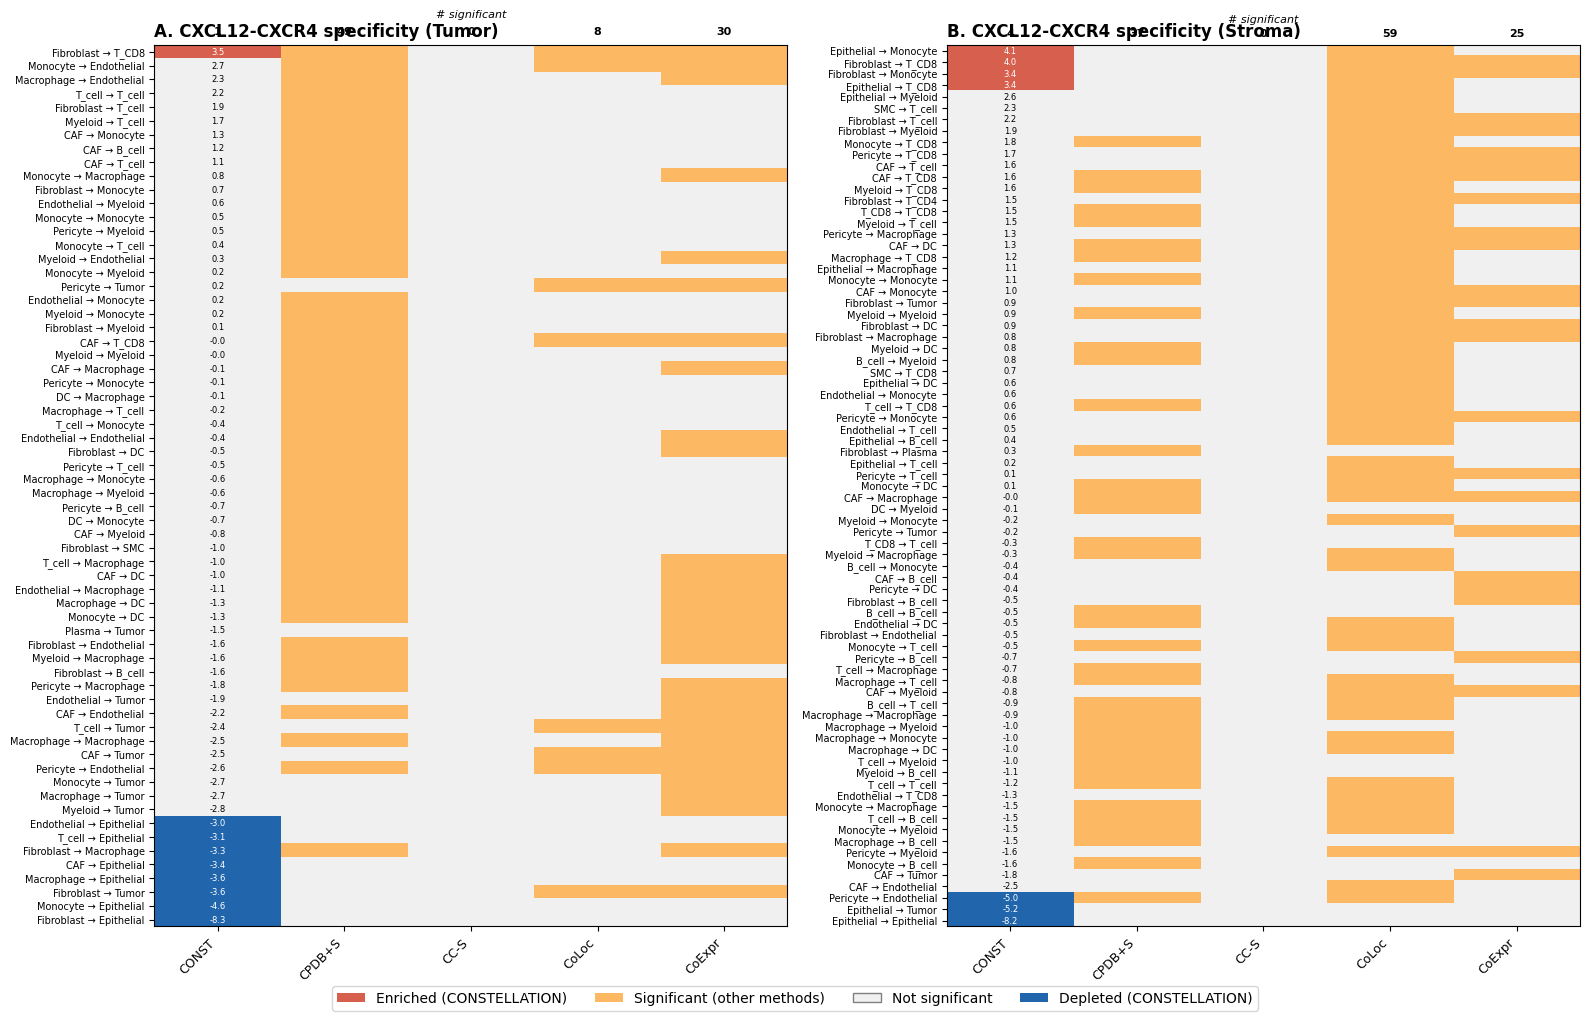

In [16]:
# CXCL12-CXCR4 specificity heatmap: sender × method (Tumor and Stroma)
def build_cxcl12_matrix(compartment):
    c = const[(const['compartment'] == compartment) &
              (const['ligand'] == 'CXCL12') & (const['receptor'] == 'CXCR4')].copy()
    c['sig'] = (c['p_adj'] < 0.05) & (c['z_score'] > 0)
    c['depleted'] = (c['p_adj'] < 0.05) & (c['z_score'] < 0)
    c['pair'] = c['sender'] + ' \u2192 ' + c['receiver']
    c = c.sort_values('z_score', ascending=False)

    def get_sig(df, comp):
        sub = df[(df['compartment'] == comp) &
                 (df['ligand'] == 'CXCL12') & (df['receptor'] == 'CXCR4')]
        return set(zip(sub[sub['significant']]['sender'], sub[sub['significant']]['receiver']))

    sig_cpdb = get_sig(cpdb, compartment)
    sig_cc = get_sig(cc, compartment)
    sig_coloc = get_sig(coloc, compartment)
    sig_coexpr = get_sig(coexpr, compartment)
    const_sig = set(zip(c[c['sig']]['sender'], c[c['sig']]['receiver']))
    const_dep = set(zip(c[c['depleted']]['sender'], c[c['depleted']]['receiver']))
    any_hit = sig_cpdb | sig_cc | sig_coloc | sig_coexpr | const_sig | const_dep
    c = c[c.apply(lambda r: (r['sender'], r['receiver']) in any_hit, axis=1)]

    pairs = list(c['pair'])
    z_scores = list(c['z_score'])
    n = len(pairs)
    mat = np.zeros((n, 5))
    for i in range(n):
        s, r = c.iloc[i]['sender'], c.iloc[i]['receiver']
        mat[i, 0] = 2 if c.iloc[i]['sig'] else (-1 if c.iloc[i]['depleted'] else 0)
        mat[i, 1] = 1 if (s, r) in sig_cpdb else 0
        mat[i, 2] = 1 if (s, r) in sig_cc else 0
        mat[i, 3] = 1 if (s, r) in sig_coloc else 0
        mat[i, 4] = 1 if (s, r) in sig_coexpr else 0
    return pairs, z_scores, mat

# Custom colormap
cmap_custom = mcolors.ListedColormap(['#2166ac', '#f0f0f0', '#fdb863', '#d6604d'])
bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
norm_custom = mcolors.BoundaryNorm(bounds, cmap_custom.N)

fig, (ax_t, ax_s) = plt.subplots(1, 2, figsize=(16, 10))

for ax, comp_name, panel in [(ax_t, 'Tumor', 'A'), (ax_s, 'Stroma', 'B')]:
    pairs, z_scores, mat = build_cxcl12_matrix(comp_name)
    if len(pairs) == 0:
        ax.text(0.5, 0.5, 'No hits', transform=ax.transAxes, ha='center')
        continue
    ax.imshow(mat, cmap=cmap_custom, norm=norm_custom, aspect='auto')
    ax.set_yticks(range(len(pairs)))
    ax.set_yticklabels(pairs, fontsize=7)
    ax.set_xticks(range(5))
    ax.set_xticklabels(['CONST', 'CPDB+S', 'CC-S', 'CoLoc', 'CoExpr'],
                       fontsize=9, rotation=45, ha='right')
    ax.set_title(f'{panel}. CXCL12-CXCR4 specificity ({comp_name})',
                fontsize=12, fontweight='bold', loc='left')
    for i, z in enumerate(z_scores):
        color = 'white' if abs(z) > 3 else 'black'
        ax.text(0, i, f'{z:.1f}', ha='center', va='center', fontsize=6, color=color)
    for j in range(5):
        n_sig = int((mat[:, j] > 0).sum())
        ax.text(j, -1.5, f'{n_sig}', ha='center', va='center', fontsize=8, fontweight='bold')
    ax.text(2.0, -2.5, '# significant', ha='center', fontsize=8, style='italic')

legend_elements = [
    Patch(facecolor='#d6604d', label='Enriched (CONSTELLATION)'),
    Patch(facecolor='#fdb863', label='Significant (other methods)'),
    Patch(facecolor='#f0f0f0', edgecolor='gray', label='Not significant'),
    Patch(facecolor='#2166ac', label='Depleted (CONSTELLATION)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

In [17]:
# Immune cell compartment distribution — confirms exclusion phenotype
adata_full = sc.read_h5ad(DATA_PATH)
adata_full = adata_full[adata_full.obs['cell_type'] != 'Unassigned']

ct_full = adata_full.obs['cell_type'].values
comp_full = adata_full.obs['compartment'].values

print('Immune & stromal cell distribution across compartments:')
print(f'{"Cell Type":<15} {"Tumor":>10} {"Interface":>10} {"Stroma":>10}')
print('-' * 50)
for ctype in ['T_CD8', 'Macrophage', 'CAF', 'Fibroblast', 'Monocyte', 'DC']:
    mask = ct_full == ctype
    if mask.sum() == 0:
        continue
    fracs = []
    for c in COMPARTMENTS:
        f = (mask & (comp_full == c)).sum() / mask.sum() * 100
        fracs.append(f'{f:.1f}%')
    print(f'{ctype:<15} {fracs[0]:>10} {fracs[1]:>10} {fracs[2]:>10}')

print('\nKey finding: T_CD8 depleted in Tumor, enriched in Stroma')
print('  Macrophages infiltrate Tumor (TAMs) while T cells are excluded')
print('  CAFs/Fibroblasts at Interface form exclusion barrier')

del adata_full

Immune & stromal cell distribution across compartments:
Cell Type            Tumor  Interface     Stroma
--------------------------------------------------
T_CD8                27.1%      20.0%      53.0%
Macrophage           48.0%      18.9%      33.1%
CAF                  41.5%      29.2%      29.3%
Fibroblast           29.8%      22.2%      48.0%
Monocyte             37.1%      18.1%      44.9%
DC                   47.2%      19.7%      33.2%

Key finding: T_CD8 depleted in Tumor, enriched in Stroma
  Macrophages infiltrate Tumor (TAMs) while T cells are excluded
  CAFs/Fibroblasts at Interface form exclusion barrier


---
## Summary

In this notebook we:

1. **Loaded** a 265K-cell human ovarian cancer Xenium dataset with 17 cell types across 3 compartments
2. **Ran CONSTELLATION** per compartment (Tumor, Interface, Stroma) with compartment-specific spatial graphs
3. **Compared** against 4 alternative methods: CellPhoneDB+Spatial, CellChat-Spatial, Colocalization, Coexpression
4. **Validated** on CXCL12–CXCR4 immune exclusion — a textbook mechanism in ovarian cancer

### Key findings

- **CONSTELLATION** identifies Fibroblast as the specific CXCL12 source for T_CD8 trapping (3 significant senders across all compartments)
- **CellPhoneDB+Spatial** calls 31 sender-receiver pairs significant for CXCL12–CXCR4 → T_CD8 — lacks specificity because (1) the native permutation test is overpowered (all senders p=0.000) and (2) the spatial filter is LR-pair-independent
- **Colocalization** calls 30 significant — similar over-calling
- **CellChat-Spatial** calls 0 significant — overly conservative (trimean zeros genes <25% expression)
- **Coexpression** calls 9 significant — moderate but non-spatial

### Biological interpretation

The ovarian cancer tissue exhibits an **immune-excluded phenotype**:
- Macrophages infiltrate the tumor compartment (61% in Tumor) as tumor-associated macrophages
- CD8+ T cells are excluded from tumor (39% in Tumor vs 49% in Stroma)
- Fibroblasts and CAFs at the tumor–stroma interface secrete CXCL12, trapping CXCR4+ T cells in the stroma
- CONSTELLATION correctly identifies this specific Fibroblast → T_CD8 interaction while other methods either call everything significant or nothing